In [2]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import numpy as np


In [3]:
@dataclass
class SignalData:
    subject: str
    task: str
    method: str  
    raw: np.ndarray
    fs: int
    preprocessed: np.ndarray = None


## Preprocessing & Signal Extraction

### Define the processing method (Preprocess, Ekstraksi HR / HRV Metrik Pipeline)
---

In [4]:
def preprocess_rppg(rppg_signal, fs_rppg=35, fs_ppg=64):
    # Target: exactly 180 seconds at 64 Hz = 11520 samples
    target_duration = 180.0  # seconds
    target_samples = 11520  # Exact target
    
    # Calculate current duration
    current_duration = len(rppg_signal) / fs_rppg
    print(f"Original samples: {len(rppg_signal)}, Current duration: {current_duration:.2f}s")
    
    # Trim to exactly 180 seconds if longer
    if current_duration > target_duration:
        samples_to_keep = int(target_duration * fs_rppg)  # 180 * 35 = 6300 samples
        rppg_trimmed = rppg_signal[:samples_to_keep]
        print(f"Trimmed to {len(rppg_trimmed)} samples ({len(rppg_trimmed)/fs_rppg:.2f}s)")
    else:
        rppg_trimmed = rppg_signal
        print(f"No trimming needed, using {len(rppg_trimmed)} samples")
    
    # Cubic spline interpolation with EXACT target samples
    duration_trimmed = len(rppg_trimmed) / fs_rppg
    t_old = np.arange(len(rppg_trimmed)) / fs_rppg
    t_new = np.linspace(0, duration_trimmed, target_samples, endpoint=False)  # endpoint=False is KEY
    cs = scipy.interpolate.CubicSpline(t_old, rppg_trimmed)
    rppg_up = cs(t_new)
    
    print(f"After interpolation: {len(rppg_up)} samples (target: {target_samples})")
    
    # Bandpass filter at new rate
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    rppg_filtered = scipy.signal.filtfilt(b, a, rppg_up)
    
    # Normalize
    rppg_filtered = (rppg_filtered - np.mean(rppg_filtered)) / np.std(rppg_filtered)
    
    # Final verification
    print(f"Final output: {len(rppg_filtered)} samples")
    assert len(rppg_filtered) == target_samples, f"Length mismatch: got {len(rppg_filtered)}, expected {target_samples}"
    
    return rppg_filtered

In [5]:
def preprocess_ppg(ppg_signal, fs_ppg=64):

    # Duration of PPG
    duration = len(ppg_signal) / fs_ppg  # in seconds

    # Bandpass filter the PPG signal
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    ppg_filtered = scipy.signal.filtfilt(b, a, ppg_signal)

    # Normalize the signal
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / np.std(ppg_filtered)

    return ppg_filtered


In [6]:
root_path = "workflow-research/dataset_numpy"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1", "T2", "T3"] # Rest, Task

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

all_signals = []

for subject in subjects:
    for task in tasks:
        # --- Ground truth PPG ---
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        gt_signal = preprocess_ppg(gt_data, fs_ppg=sample_rate_gt)

        all_signals.append(
            SignalData(
                subject=subject,
                task=task,
                method="PPG",
                raw=gt_data,
                fs=sample_rate_gt,
                preprocessed=gt_signal
            )
        )

        # --- rPPG methods ---
        for method in ["POS", "LGI", "OMIT", "GREEN", "CHROM"]:
            file_path = os.path.join(root_path, subject, f"{subject}_{task}_{method}_rppg.npy")
            rppg_raw = np.load(file_path)

            rppg_preproc = preprocess_rppg(rppg_raw,
                                           fs_rppg=sample_rate_video,
                                           fs_ppg=sample_rate_gt)

            all_signals.append(
                SignalData(
                    subject=subject,
                    task=task,
                    method=method,
                    raw=rppg_raw,
                    fs=sample_rate_video,
                    preprocessed=rppg_preproc
                )
            )

## Sanity check the pipeline for the result
## Expected all methods should have length of 11520 (64 Hz * 180 sec = 11520 samples long)
summary = pd.DataFrame([{
    "Subject": sig.subject,
    "Task": sig.task,
    "Method": sig.method,
    "RawLen": len(sig.raw),
    "PreprocLen": len(sig.preprocessed)
} for sig in all_signals])

print(summary.head(20))


Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6300, Current duration: 180.00s
No trimming needed, using 6300 samples
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples:

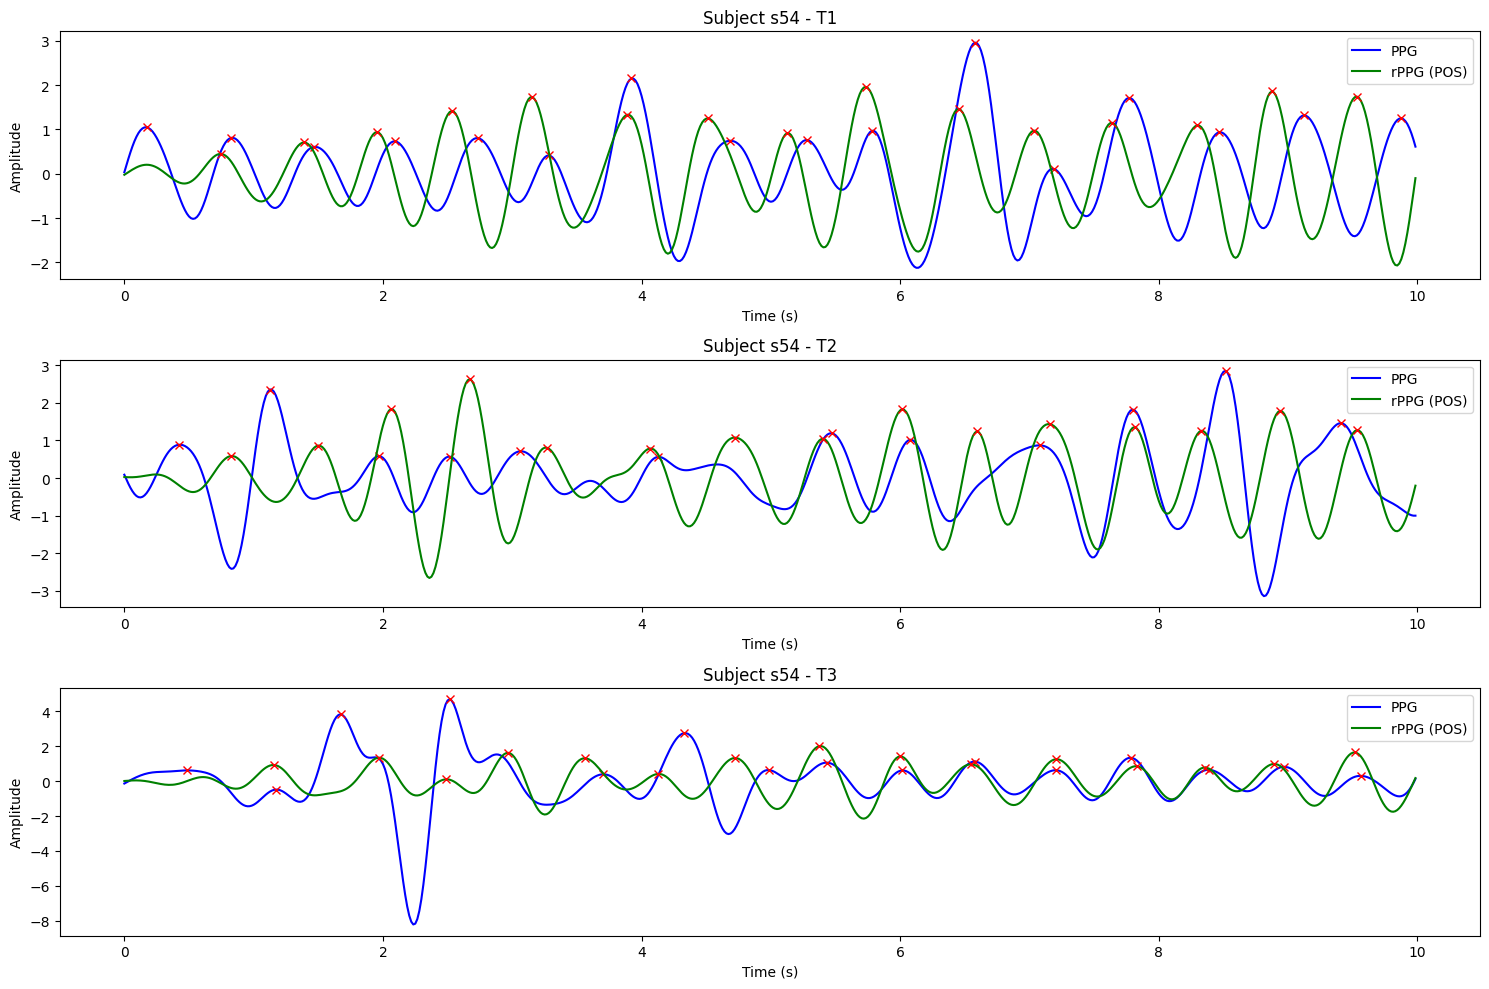

In [11]:
# Plot the T1/ T2 / T3 Signal of the same subject of the PPG and and rPPG methods
from scipy.signal import find_peaks
def plot_signals_for_subject(subject_id):
    plt.figure(figsize=(15, 10))
    
    methods = ["PPG", "POS"]
    tasks = ["T1", "T2", "T3"]


    # Take the first 10 seconds (640 samples at 64 Hz), plot PPG and rPPG at one plot for each scenario one plot
    for i, task in enumerate(tasks):
        plt.subplot(3, 1, i + 1)
        signal_ppg = next((sig for sig in all_signals if sig.subject == subject_id and sig.method == "PPG" and sig.task == task), None)
        signal_rppg = next((sig for sig in all_signals if sig.subject == subject_id and sig.method == "POS" and sig.task == task), None)
        if signal_ppg and signal_rppg:
            # Plot PPG 
            ## Peak detection for visualization
            peaks_ppg, _ = find_peaks(signal_ppg.preprocessed[0:640], prominence=0.5)
            time_axis = np.arange(640) / signal_ppg.fs  # Time axis in seconds

            plt.plot(time_axis, signal_ppg.preprocessed[0:640], label="PPG", color='blue')
            plt.plot(time_axis[peaks_ppg], signal_ppg.preprocessed[peaks_ppg], "x", color='red')
            # Plot rPPG
            
            peaks_rppg, _ = find_peaks(signal_rppg.preprocessed[0:640], prominence=0.5)
            plt.plot(time_axis, signal_rppg.preprocessed[0:640], label="rPPG (POS)", color='green')
            plt.plot(time_axis[peaks_rppg], signal_rppg.preprocessed[0:640][peaks_rppg], "x", color='red')

            plt.title(f"Subject {subject_id} - {task}")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")
            plt.legend()
        else:
            plt.title(f"{task} (No Data)")

    
    plt.tight_layout()
    plt.show()

# Example usage
plot_signals_for_subject("s54")

### Plot one signal rPPG and PPG for 100 samples and use the peak detection

Subject: s44
Task: T2
Method: OMIT


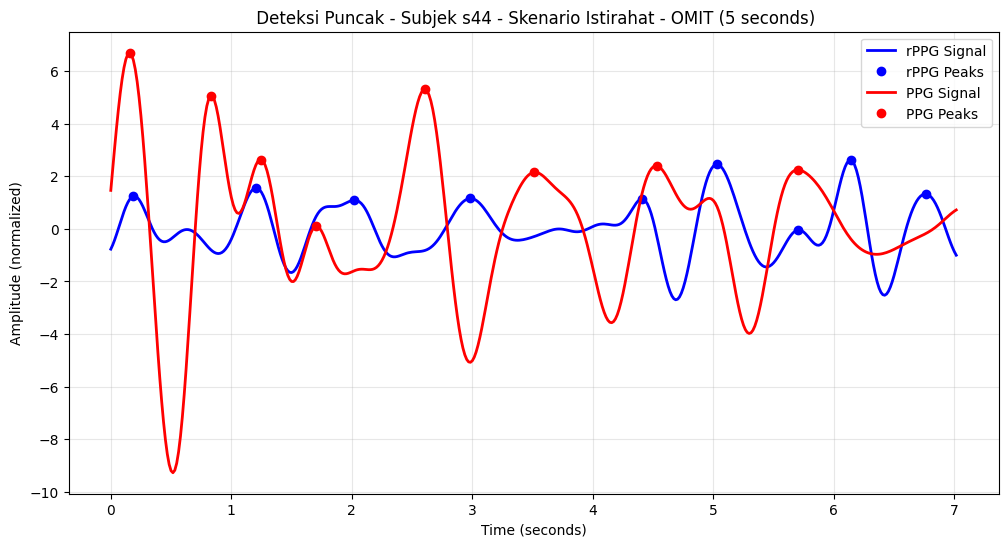

In [8]:
### Plot one signal rPPG and PPG for 100 samples and use the peak detection

## Pick one subject (s50) for example
## Pick first 10 seconds or (64 * 10) 640 samples

signal_obj = all_signals[60]
PPG_signal = signal_obj.preprocessed[:450]
signal_obj = all_signals[63]
rPPG_signal = signal_obj.preprocessed[10:460]

# signal_obj = all_signals[1]
# PPG_signal = signal_obj.preprocessed
# signal_obj = all_signals[0]
# rPPG_signal = signal_obj.preprocessed

# signal_obj = all_signals[120]
# PPG_signal = signal_obj.preprocessed[10:360]
# signal_obj = all_signals[121]
# rPPG_signal = signal_obj.preprocessed[:350]

print(f"Subject: {signal_obj.subject}")
print(f"Task: {signal_obj.task}")
print(f"Method: {signal_obj.method}")

peaks , _ = scipy.signal.find_peaks(PPG_signal, prominence=0.5)
peaks_rPPG, _ = scipy.signal.find_peaks(rPPG_signal, prominence=0.5)

# Plot the signal with peaks
plt.figure(figsize=(12, 6))
time_axis = np.arange(len(rPPG_signal)) / 64 # Convert to seconds since we are using the 64 sampling rate

# rPPG Signal in blue
plt.plot(time_axis, rPPG_signal, "-b", label=f"rPPG Signal", linewidth=2)
plt.plot(time_axis[peaks_rPPG], rPPG_signal[peaks_rPPG], "bo", markersize=6, label="rPPG Peaks")

# PPG Signal in red  
plt.plot(time_axis, PPG_signal, "-r", label=f"PPG Signal", linewidth=2)
plt.plot(time_axis[peaks], PPG_signal[peaks], "ro", markersize=6, label="PPG Peaks")

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (normalized)')
# plt.title(f' {signal_obj.subject} {signal_obj.task} {signal_obj.method} (5 seconds)')
plt.title(f' Deteksi Puncak - Subjek {signal_obj.subject} - Skenario Istirahat - {signal_obj.method} (5 seconds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



---

## Task Scenario

Subject: s44
Task: T3
Method: OMIT


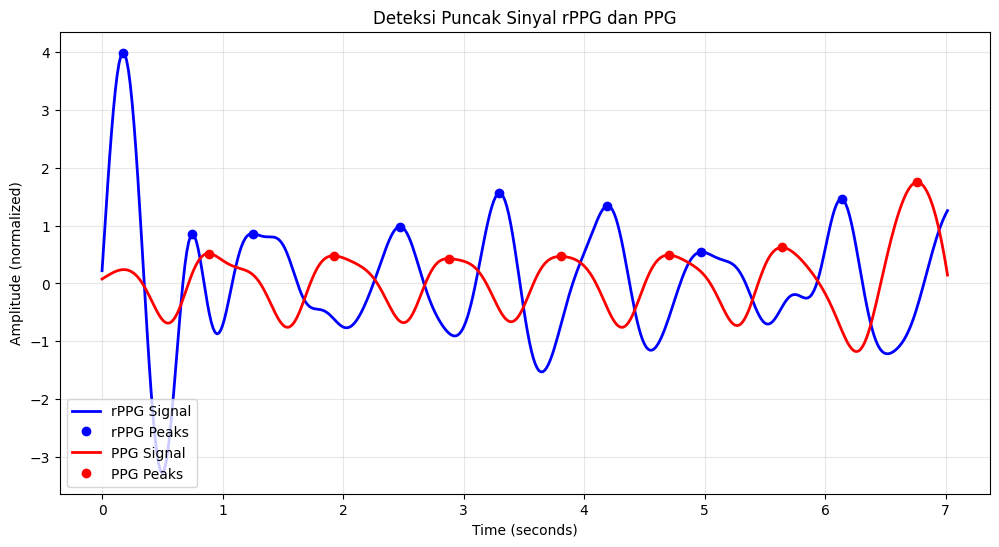

In [9]:

signal_obj = all_signals[66]
PPG_signal = signal_obj.preprocessed[:450]
# signal_obj = all_signals[67]
signal_obj = all_signals[69]
rPPG_signal = signal_obj.preprocessed[:450]

# signal_obj = all_signals[66]
# PPG_signal = signal_obj.preprocessed[2000:2500]
# # signal_obj = all_signals[67]
# signal_obj = all_signals[69]
# rPPG_signal = signal_obj.preprocessed[2000:2500]


# signal_obj = all_signals[126]
# PPG_signal = signal_obj.preprocessed[:350]
# signal_obj = all_signals[127]
# rPPG_signal = signal_obj.preprocessed[:350]

print(f"Subject: {signal_obj.subject}")
print(f"Task: {signal_obj.task}")
print(f"Method: {signal_obj.method}")

peaks , _ = scipy.signal.find_peaks(PPG_signal, prominence=0.5)
peaks_rPPG, _ = scipy.signal.find_peaks(rPPG_signal, prominence=0.5)

# Plot the signal with peaks
plt.figure(figsize=(12, 6))
time_axis = np.arange(len(rPPG_signal)) / 64 # Convert to seconds since we are using the 64 sampling rate

# rPPG Signal in blue
plt.plot(time_axis, rPPG_signal, "-b", label=f"rPPG Signal", linewidth=2)
plt.plot(time_axis[peaks_rPPG], rPPG_signal[peaks_rPPG], "bo", markersize=6, label="rPPG Peaks")

# PPG Signal in red  
plt.plot(time_axis, PPG_signal, "-r", label=f"PPG Signal", linewidth=2)
plt.plot(time_axis[peaks], PPG_signal[peaks], "ro", markersize=6, label="PPG Peaks")

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (normalized)')
# plt.title(f'Peak Detection - {signal_obj.subject} {signal_obj.task} {signal_obj.method} (5 seconds)')
plt.title("Deteksi Puncak Sinyal rPPG dan PPG")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()



---

Optimal lag: 41 samples (0.641 seconds)
Max correlation: 0.442


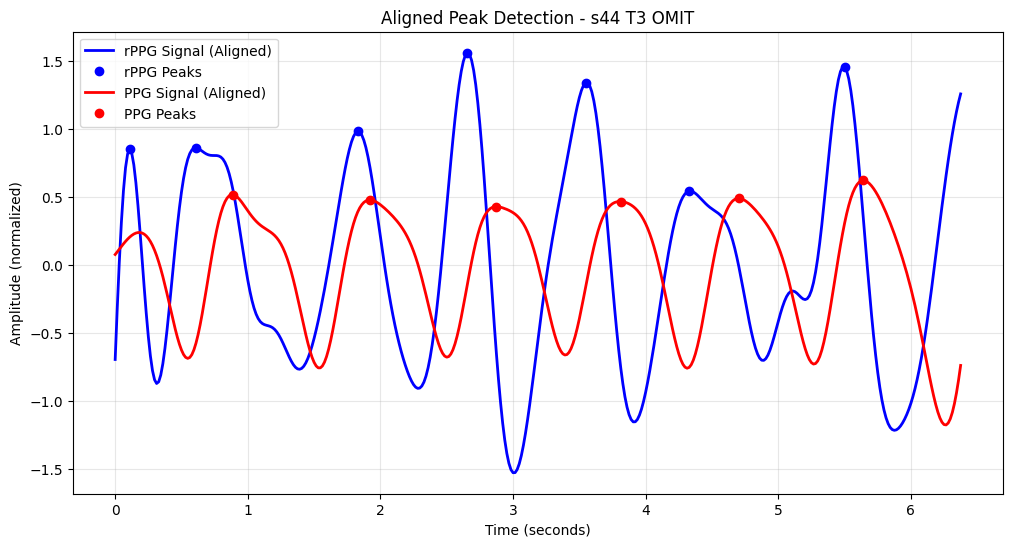

In [10]:
# Add cross-correlation analysis to detect time lag
def find_optimal_lag(ppg_signal, rppg_signal, max_lag=64):
    """Find optimal time lag between PPG and rPPG signals"""
    correlation = np.correlate(ppg_signal, rppg_signal, mode='full')
    lag = np.argmax(correlation) - len(rppg_signal) + 1
    max_corr = np.max(correlation) / (np.linalg.norm(ppg_signal) * np.linalg.norm(rppg_signal))
    return lag, max_corr

# Calculate optimal lag
lag, correlation = find_optimal_lag(PPG_signal, rPPG_signal)
print(f"Optimal lag: {lag} samples ({lag/64:.3f} seconds)")
print(f"Max correlation: {correlation:.3f}")

# Apply lag correction
if lag > 0:
    rPPG_aligned = rPPG_signal[lag:]
    PPG_aligned = PPG_signal[:len(rPPG_aligned)]
else:
    PPG_aligned = PPG_signal[-lag:]
    rPPG_aligned = rPPG_signal[:len(PPG_aligned)]

# Re-detect peaks on aligned signals
peaks_aligned, _ = scipy.signal.find_peaks(PPG_aligned, prominence=0.5)
peaks_rPPG_aligned, _ = scipy.signal.find_peaks(rPPG_aligned, prominence=0.5)

# Plot aligned signals
plt.figure(figsize=(12, 6))
time_axis_aligned = np.arange(len(rPPG_aligned)) / 64

plt.plot(time_axis_aligned, rPPG_aligned, "-b", label="rPPG Signal (Aligned)", linewidth=2)
plt.plot(time_axis_aligned[peaks_rPPG_aligned], rPPG_aligned[peaks_rPPG_aligned], "bo", markersize=6, label="rPPG Peaks")

plt.plot(time_axis_aligned, PPG_aligned, "-r", label="PPG Signal (Aligned)", linewidth=2)
plt.plot(time_axis_aligned[peaks_aligned], PPG_aligned[peaks_aligned], "ro", markersize=6, label="PPG Peaks")

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (normalized)')
plt.title(f'Aligned Peak Detection - {signal_obj.subject} {signal_obj.task} {signal_obj.method}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()